### Read SNOWPACK Output at TRAM with HRRR-AK WY2023-WY2025

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
ds_snowpack_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_met_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet")
# ds_snowpack_met_hrrrak_ffill, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_ffill_tram_WY2023-WY2025_base.smet")

/tmp/ipykernel_82952/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_82952/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [6]:
ds_snowpack_hrrrak

<xarray.Dataset> Size: 27MB
Dimensions:               (timestamp: 51884)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 415kB 2019-10-01T05:00:0...
Data variables: (12/63)
    Qs                    (timestamp) float64 415kB 652.7 728.4 ... 115.6 90.14
    Ql                    (timestamp) float64 415kB 672.1 750.0 ... 129.7 96.0
    Qg                    (timestamp) float64 415kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 415kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 415kB -999.0 -999.0 ... -999.0
    Qr                    (timestamp) float64 415kB 20.17 18.85 ... 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 415kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Ss                    (timestamp) float64 415kB 6.0 6.0 6.0 ... 6.0 6.0 6.0
    zS4                   (timestamp) float64 415kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S4                    (timestamp) float64 415kB 6.0 6.0 6.0 ... 6.0 6.0 6.0
    zS5                   (timestamp) float64 415kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S5                    (timestamp) float64 415kB -999.0 -999.0 ... -999.0

In [7]:
# cut the ds_snowpack_hrrrak to WY2023-WY2025 to match the met forcing snowpack run
# ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(timestamp=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

### Open Observations

In [8]:
file = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs = xr.open_dataset(file)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_obs = ds_obs.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

# convert temp to K for comparison with HRRR-AK data
# ds_obs['temp'] = ds_obs['temp'] + 273.15

In [ ]:
# ds_snowpack_hrrrak
# ds_snowpack_met_hrrrak
# ds_obs

Text(0, 0.5, 'snow depth (cm)')

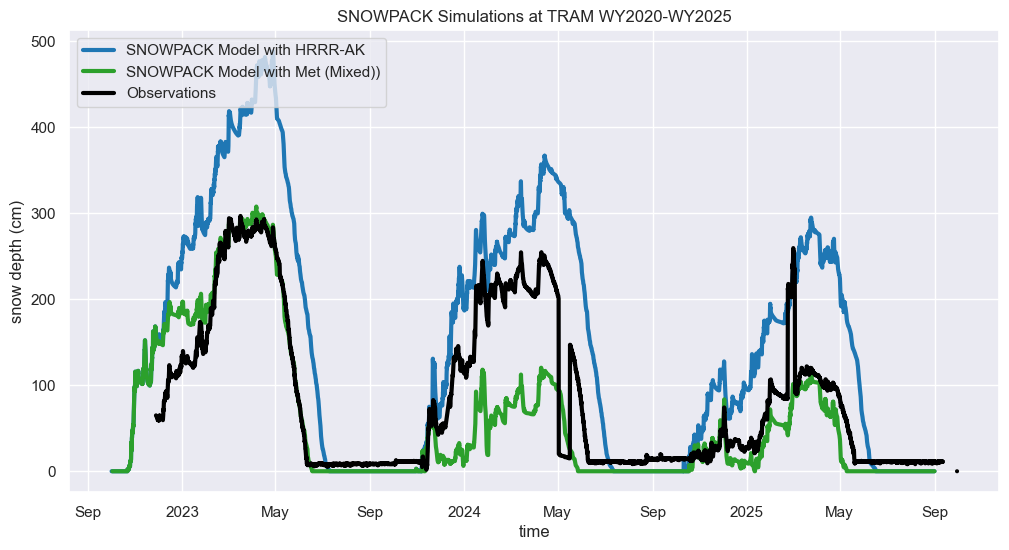

In [10]:
ds_snowpack_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
ds_snowpack_met_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')

ds_obs.hs.plot(label = 'Observations', linewidth = 3, color='black')


plt.title('SNOWPACK Simulations at TRAM WY2020-WY2025')
plt.legend(loc='upper left')

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

### SWE

Text(0, 0.5, 'SWE (mm)')

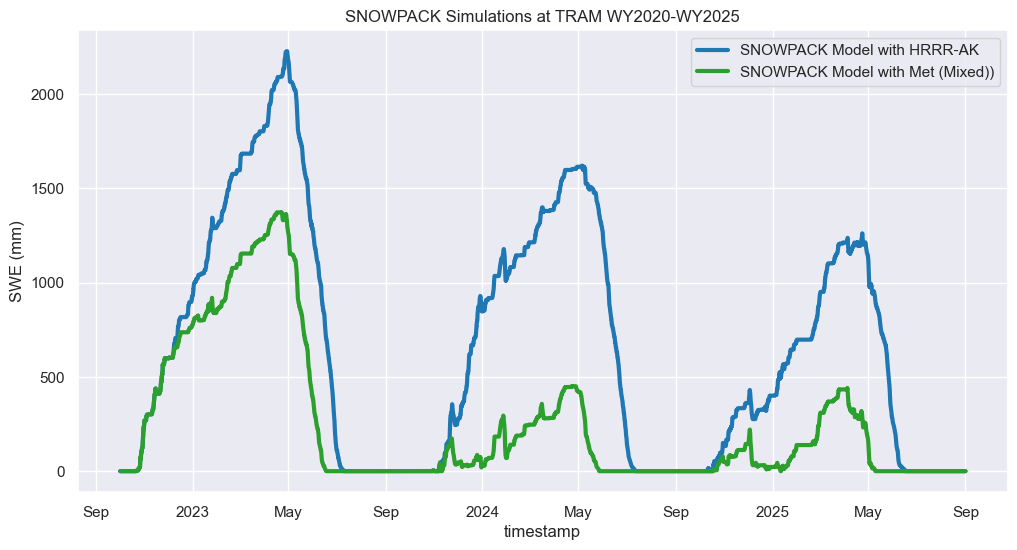

In [11]:
ds_snowpack_hrrrak.SWE.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
ds_snowpack_met_hrrrak.SWE.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.SWE.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')

# (ds_obs.swe*10).plot(label = 'Observations', linewidth = 3, color='black') # convert SWE to mm 


plt.title('SNOWPACK Simulations at TRAM WY2020-WY2025')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('SWE (mm)')